In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv(r"C:\Users\hassa\OneDrive\سطح المكتب\Programing subject\Machine-Learning\Lab4\best _sellin_books_2023.csv", encoding='ISO-8859-1')
df.head(10)

,id,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre
0,#1,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$18.88,NaN,320.0,16/10/2018,Self-Improvement
1,#2,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$11.05,NaN,640.0,07/11/2023,Fiction & Action & Adventure
2,#3,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$11.99,NaN,416.0,"January 10, 2023",Biographies & Memoirs
3,#4,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$13.62,NaN,544.0,17/09/2024,Fiction & Action & Adventure
4,#5,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$11.37,NaN,288.0,"October 24, 2023",Biographies & Memoirs
5,#6,Lessons in Chemistry: A Novel,Bonnie Garmus,4.6 out of 5 stars,322650,Hardcover,$13.94,NaN,400.0,"April 5, 2022",Fiction & Action & Adventure
6,#7,The 48 Laws of Power,Robert Greene,4.7 out of 5 stars,87375,Paperback,$13.99,NaN,452.0,01/09/2000,Politics & Social Sciences
7,#8,"The Body Keeps the Score: Brain, Mind, and Bod...",Bessel van der Kolk M.D.,4.8 out of 5 stars,82564,Paperback,$14.39,18 years and up,464.0,08/09/2015,Health & Fitness & Dieting
8,#9,It Starts with Us: A Novel (It Ends with Us),Colleen Hoover,4.5 out of 5 stars,228242,Paperback,$1.88,NaN,336.0,18/10/2022,Fiction & Action & Adventure
9,#10,Outlive: The Science and Art of Longevity,Peter Attia MD,4.6 out of 5 stars,19946,Hardcover,$18.00,NaN,496.0,28/03/2023,Health & Fitness & Dieting


# task1 

In [5]:
df.dtypes

id                  object
Book name           object
Author              object
Rating              object
reviews count        int64
form                object
price               object
Reading age         object
Print Length       float64
Publishing date     object
Genre               object
dtype: object

In [49]:
# Remove currency symbols/commas and convert to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
# Convert to numeric, turning non-numeric strings into NaN
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Publishing date'] = pd.to_datetime(df['Publishing date'], errors='coerce')

# Drop any remaining NaNs in these specific columns
X = df_standardized[['price', 'Print Length']].dropna()

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

df.dtypes

Explained Variance Ratio: [0.74530084 0.25469916]


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\hassa\AppData\Local\Temp\ipykernel_20196\1200025597.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


id                         object
Book name                  object
Author                     object
Rating                    float64
reviews count               int64
form                       object
price                     float64
Reading age                object
Print Length              float64
Publishing date    datetime64[ns]
Genre                      object
dtype: object

In [51]:
df.isna().sum()

id                   0
Book name            0
Author               0
Rating             100
reviews count        0
form                 0
price                0
Reading age         70
Print Length         2
Publishing date     58
Genre                0
dtype: int64

In [53]:
df.shape

(100, 11)

# task2

# This is best for numerical data that follows a Normal Distribution

In [56]:
df_mean = df.copy()

# Fill missing values in 'Print Length' with the mean
df_mean['Print Length'] = df_mean['Print Length'].fillna(df_mean['Print Length'].mean())

# Check
print("Missing values after Mean Imputation:")
print(df_mean.isna().sum())

Missing values after Mean Imputation:
id                   0
Book name            0
Author               0
Rating             100
reviews count        0
form                 0
price                0
Reading age         70
Print Length         0
Publishing date     58
Genre                0
dtype: int64


# We have small NaN so it's the fastest way

In [59]:
df_dropped = df.copy()

# Remove only the rows where 'Print Length' is missing (2 rows)
df_dropped = df_dropped.dropna(subset=['Print Length'])

print(f"Original shape: {df.shape}")
print(f"Shape after dropping rows with missing Print Length: {df_dropped.shape}")

Original shape: (100, 11)
Shape after dropping rows with missing Print Length: (98, 11)


# the whole values are missing so nothing can work

In [62]:
# Drop 'Rating' because it is 100% empty
df_clean = df.drop(columns=['Rating'])

# task3

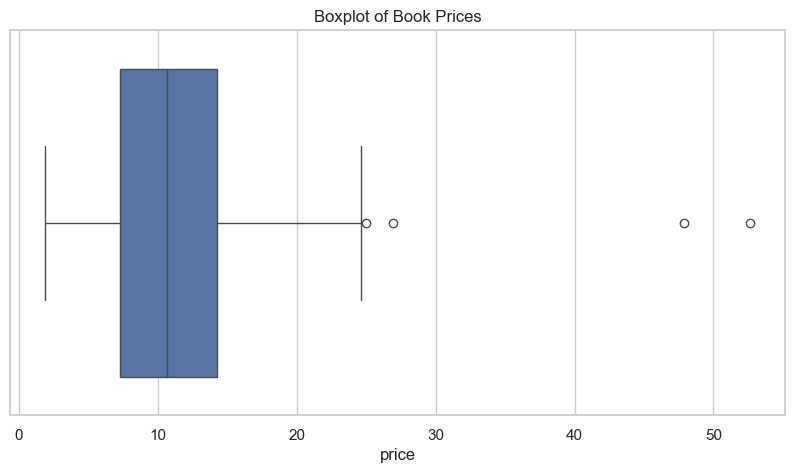

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Book Prices')
plt.show()

In [65]:
# Calculate quartiles for 'price'
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Total outliers detected: {len(outliers)}")
outliers.head(15)

Total outliers detected: 4


,id,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre
40,#41,Fourth Wing (Special Edition),Rebecca Yarros,NaN,5028,Hardcover,26.91,NaN,528.0,NaT,Fiction & Action & Adventure
71,#72,A Court of Thorns and Roses Paperback Box Set ...,Sarah J. Maas,NaN,52380,Paperback,47.90,NaN,2896.0,2022-11-01,Fiction & Action & Adventure
75,#76,Can't Hurt Me: Master Your Mind and Defy the Odds,David Goggins,NaN,104512,Paperback,24.99,NaN,364.0,NaT,Self-Improvement
80,#81,Harry Potter Paperback Box Set,"J. K. Rowling, Mary GrandPre?",NaN,65142,Paperback,52.62,9 years and up,NaN,NaT,Reading & Writing


In [68]:
# Define capping limits (e.g., 5th and 95th percentiles)
lower_cap = df['price'].quantile(0.05)
upper_cap = df['price'].quantile(0.95)

# Apply capping
df_capped = df.copy()
df_capped['price'] = df_capped['price'].clip(lower_cap, upper_cap)

print("Outliers have been capped at the 5th and 95th percentiles.")

Outliers have been capped at the 5th and 95th percentiles.


# task4

# MIN & MAX

In [71]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Select columns to scale
cols_to_scale = ['price', 'Print Length']

# Apply scaling
df_scaled = df_capped.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

df_scaled[cols_to_scale].head()

,price,Print Length
0,0.770352,0.103064
1,0.397912,0.214485
2,0.442624,0.136490
3,0.520156,0.181058
4,0.413133,0.091922


# Z-score

In [74]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
std_scaler = StandardScaler()

# Apply standardization
df_standardized = df_capped.copy()
df_standardized[cols_to_scale] = std_scaler.fit_transform(df_standardized[cols_to_scale])

df_standardized[cols_to_scale].head()

,price,Print Length
0,1.394923,-0.125282
1,-0.054848,0.847201
2,0.119199,0.166463
3,0.421003,0.555456
4,0.004402,-0.222530


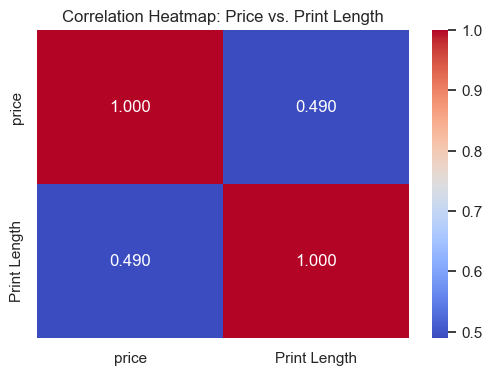

In [76]:
# 1. Select the numerical features you want to compare
# In this lab, we use 'price' and 'Print Length'
numerical_df = df_standardized[['price', 'Print Length']]

# 2. Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# 3. Create the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, 
            annot=True,      # This shows the numbers inside the boxes
            cmap="coolwarm", # Red for positive, blue for negative correlation
            fmt=".3f")       # Format to 3 decimal places

plt.title("Correlation Heatmap: Price vs. Print Length")
plt.show()

# task5

In [77]:
from sklearn.decomposition import PCA

# Select your features
X = df_standardized[['price', 'Print Length']]

# FIX: Drop rows with any missing values in these two columns
X_clean = X.dropna()

# Initialize and fit PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_clean)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.74530084 0.25469916]


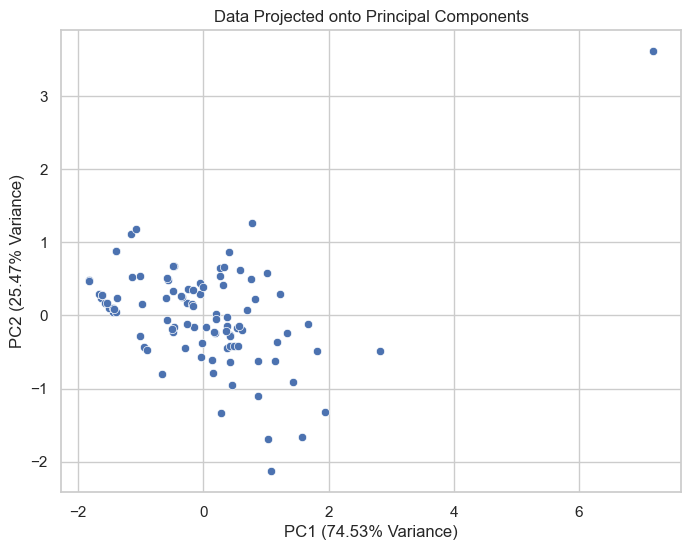

In [80]:
# Create a DataFrame for the new components
pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pc_df)
plt.title('Data Projected onto Principal Components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.show()